In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())

I0000 00:00:1778952260.138531    5271 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.21.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [2]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input, mixed_precision
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
)

In [13]:
# ─────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────
IMG_SIZE   = 256
BATCH_SIZE = 4
EPOCHS     = 100
DATA_PATH  = '/mnt/c/development/Thesis/PolypSegmentationBasedClassification/DataSets/PolypGen2021_MultiCenterData_v2'
MODEL_SAVE = '/mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unet-trsenet/depth-se-polypgen/best_unet_depthwise_3x3_5x5_7x7_se_v16PM.keras'

In [4]:
import tensorflow as tf

def augment(img, mask):
    # 1. Horizontal Flip:  Both Image and Mask will be flipped
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # 2. Vartical Flip:  Both Image and Mask will be flipped
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # 3. Brightness adjustment only for Image not mask
    img = tf.image.random_brightness(img, max_delta=0.15)

    # 4. Contrust Adjustment
    # Colab/Drive Crush handle management
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)

    # 5. Value Clipping
    img = tf.clip_by_value(img, 0.0, 1.0)

    # 6. Shape Gradient, Crusial for medical image pipeline
    # After augmentation no chance to loss the shape
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return img, mask

In [5]:
import os
import glob

def load_segmentation_paths(base_path):
    all_images = []
    all_masks = []

    # Taking Loop from C1 to C6
    for i in range(1, 7):
        center_id = f"C{i}"

        img_dir = os.path.join(base_path, f"data_{center_id}", f"images_{center_id}")
        mask_dir = os.path.join(base_path, f"data_{center_id}", f"masks_{center_id}")

        if os.path.exists(img_dir) and os.path.exists(mask_dir):
            # 1. Loading All the images from image folders
            img_paths = (glob.glob(os.path.join(img_dir, "*.jpg")) +
                         glob.glob(os.path.join(img_dir, "*.JPG")) +
                         glob.glob(os.path.join(img_dir, "*.png")) +
                         glob.glob(os.path.join(img_dir, "*.jpeg")))

            #
            for img_p in img_paths:
                filename = os.path.basename(img_p)  #  '425OLCV1_100H0018.jpg'
                name_without_ext, ext = os.path.splitext(filename) # '425OLCV1_100H0018', '.jpg'

                #
                expected_mask_name = f"{name_without_ext}_mask{ext}" # '425OLCV1_100H0018_mask.jpg'
                mask_p = os.path.join(mask_dir, expected_mask_name)

                #
                if os.path.exists(mask_p):
                    all_images.append(img_p)
                    all_masks.append(mask_p)

            print(f"✅ Center {center_id} loaded: {len(img_paths)} images found. Matches successfully paired!")
        else:
            print(f"⚠️ Center {center_id} Folder path not found")

    return all_images, all_masks


In [6]:
images_list, masks_list = load_segmentation_paths(DATA_PATH)
print(f"\nTotal Parsed Images: {len(images_list)}")
print(f"Total Parsed Masks: {len(masks_list)}")

✅ Center C1 loaded: 256 images found. Matches successfully paired!
✅ Center C2 loaded: 301 images found. Matches successfully paired!
✅ Center C3 loaded: 457 images found. Matches successfully paired!
✅ Center C4 loaded: 227 images found. Matches successfully paired!
✅ Center C5 loaded: 208 images found. Matches successfully paired!
✅ Center C6 loaded: 88 images found. Matches successfully paired!

Total Parsed Images: 1536
Total Parsed Masks: 1536


In [7]:

import tensorflow as tf

# ─────────────────────────────────────────────
#  UPDATED PROCESS PATH FUNCTION
# ─────────────────────────────────────────────
def process_path_segmentation(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])

    # Mask Processing
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_image(mask, channels=1, expand_animations=False)
    mask = tf.image.resize(mask, [IMG_SIZE, IMG_SIZE],
                           method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    mask.set_shape([IMG_SIZE, IMG_SIZE, 1]) # মাস্কের শেপ ফিক্সড করা

    return img, mask



In [8]:

# ─────────────────────────────────────────────
# 2. UPDATED DATASET GENERATOR FUNCTION
# ─────────────────────────────────────────────
def get_dataset(x, y, batch=BATCH_SIZE, augment_data=False):

    ds = tf.data.Dataset.from_tensor_slices((x, y))
    ds = ds.shuffle(buffer_size=len(x), reshuffle_each_iteration=True)
    ds = ds.map(process_path_segmentation, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)


    ds = ds.batch(batch)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds



In [9]:
# ─────────────────────────────────────────────
#  LOSS & METRICS
# ─────────────────────────────────────────────
def dice_coef(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    y_true_f = tf.cast(y_true, tf.float32)
    y_pred_f = tf.cast(y_pred, tf.float32)
    bce = tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(y_true_f, y_pred_f)
    )
    return bce + dice_loss(y_true_f, y_pred_f)

def iou_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + 1.0) / (union + 1.0)


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

def se_block(input_tensor, ratio=16):
    """Squeeze-and-Excitation Block"""
    channels = input_tensor.shape[-1]

    # Squeeze: Global Information Capture
    # (Batch, H, W, C) -> (Batch, 1, 1, C)
    squeeze = layers.GlobalAveragePooling2D()(input_tensor)

    # Excitation: Learning channel-wise weights
    excitation = layers.Dense(channels // ratio, activation='relu', use_bias=False)(squeeze)
    excitation = layers.Dense(channels, activation='sigmoid', use_bias=False)(excitation)

    # Reshape for multiplication
    excitation = layers.Reshape((1, 1, channels))(excitation)

    # Scale: Multiply original input by learned weights
    return layers.multiply([input_tensor, excitation])



In [11]:
def depthwise_seperable_conv_block(x, filters, dropout_rate=0.0):
    """Depthwise Separable Conv -> SE Block -> BN -> ReLU"""
    # First apply 3x3 karnel
    x = layers.SeparableConv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)
    # Second apply 5x5 karnel
    x = layers.SeparableConv2D(filters, 5, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Third apply 7x7
    x = layers.SeparableConv2D(filters, 7, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = se_block(x)

    return x



In [12]:
def build_unet_depthwise_seperable_se_lite(input_shape=(256, 256, 3)):
    inputs = Input(input_shape)

    # ── Encoder (Downsampling) ──────────────────
    c1 = depthwise_seperable_conv_block(inputs, 32)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = depthwise_seperable_conv_block(p1, 64)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = depthwise_seperable_conv_block(p2, 128, dropout_rate=0.1)
    p3 = layers.MaxPooling2D(2)(c3)

    c4 = depthwise_seperable_conv_block(p3, 256, dropout_rate=0.2)
    p4 = layers.MaxPooling2D(2)(c4)

    # ── Bottleneck ──────────────────────────────
    b = depthwise_seperable_conv_block(p4, 512, dropout_rate=0.3)

    # ── Decoder (Upsampling) ────────────────────
    u4 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(b)
    u4 = layers.concatenate([u4, c4])
    c5 = depthwise_seperable_conv_block(u4, 256, dropout_rate=0.2)

    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(c5)
    u3 = layers.concatenate([u3, c3])
    c6 = depthwise_seperable_conv_block(u3, 128, dropout_rate=0.1)

    u2 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c6)
    u2 = layers.concatenate([u2, c2])
    c7 = depthwise_seperable_conv_block(u2, 64)

    u1 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c7)
    u1 = layers.concatenate([u1, c1])
    c8 = depthwise_seperable_conv_block(u1, 32)

    # Output Layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid', dtype='float32')(c8)

    return models.Model(inputs, outputs, name='Depthwise-Seperable-SE-Net-3x5x7')


✅ Center C1 loaded: 256 images found. Matches successfully paired!
✅ Center C2 loaded: 301 images found. Matches successfully paired!
✅ Center C3 loaded: 457 images found. Matches successfully paired!
✅ Center C4 loaded: 227 images found. Matches successfully paired!
✅ Center C5 loaded: 208 images found. Matches successfully paired!
✅ Center C6 loaded: 88 images found. Matches successfully paired!

Total Parsed Images: 1536 | Total Parsed Masks: 1536
Train samples: 1228  |  Val samples: 308


W0000 00:00:1778952782.451737    5271 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1778952782.452782    5271 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "Depthwise-Seperable-SE-Net-3x5x7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 256, 256,  │        123 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 256, 256,  │      1,824 │ activation[0][0]  │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 256, 256,  │      2,592 │ activation_1[0][… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation_2[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │         64 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │         64 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 256, 256,  │          0 │ activation_2[0][… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ multiply[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 128, 128,  │      2,336 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ separable_conv2d

 Total params: 2,111,644 (8.06 MB)

 Trainable params: 2,102,812 (8.02 MB)

 Non-trainable params: 8,832 (34.50 KB)


========== Training Started ==========
Epoch 1/100


I0000 00:00:1778952802.015279    8343 service.cc:153] XLA service 0x76d668093cc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778952802.015342    8343 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778952802.498418    8343 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778952807.271270    8343 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778952808.147069    8343 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31268__.386
E0000 00:00:1778952833.231079    8343 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778952834.347550    8343 cuda_timer.cc:87] Delay kernel time

307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8358 - dice_coef: 0.1608 - iou_metric: 0.1042 - loss: 1.2985
Epoch 1: val_dice_coef improved from None to 0.16153, saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unet-trsenet/depth-se-polypgen/best_unet_depthwise_3x3_5x5_7x7_se_v16PM.keras

Epoch 1: finished saving model to /mnt/c/development/Thesis/PolypSegmentationBasedClassification/models/unet-trsenet/depth-se-polypgen/best_unet_depthwise_3x3_5x5_7x7_se_v16PM.keras
307/307 ━━━━━━━━━━━━━━━━━━━━ 132s 112ms/step - accuracy: 0.8737 - dice_coef: 0.1785 - iou_metric: 0.1170 - loss: 1.1851 - val_accuracy: 0.9195 - val_dice_coef: 0.1615 - val_iou_metric: 4.0950e-04 - val_loss: 1.1383 - learning_rate: 0.0010
Epoch 2/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8785 - dice_coef: 0.2256 - iou_metric: 0.1662 - loss: 1.0525
Epoch 2: val_dice_coef improved from 0.16153 to 0.24582, saving model to /mnt/c/development/Thesis/PolypSegmentati

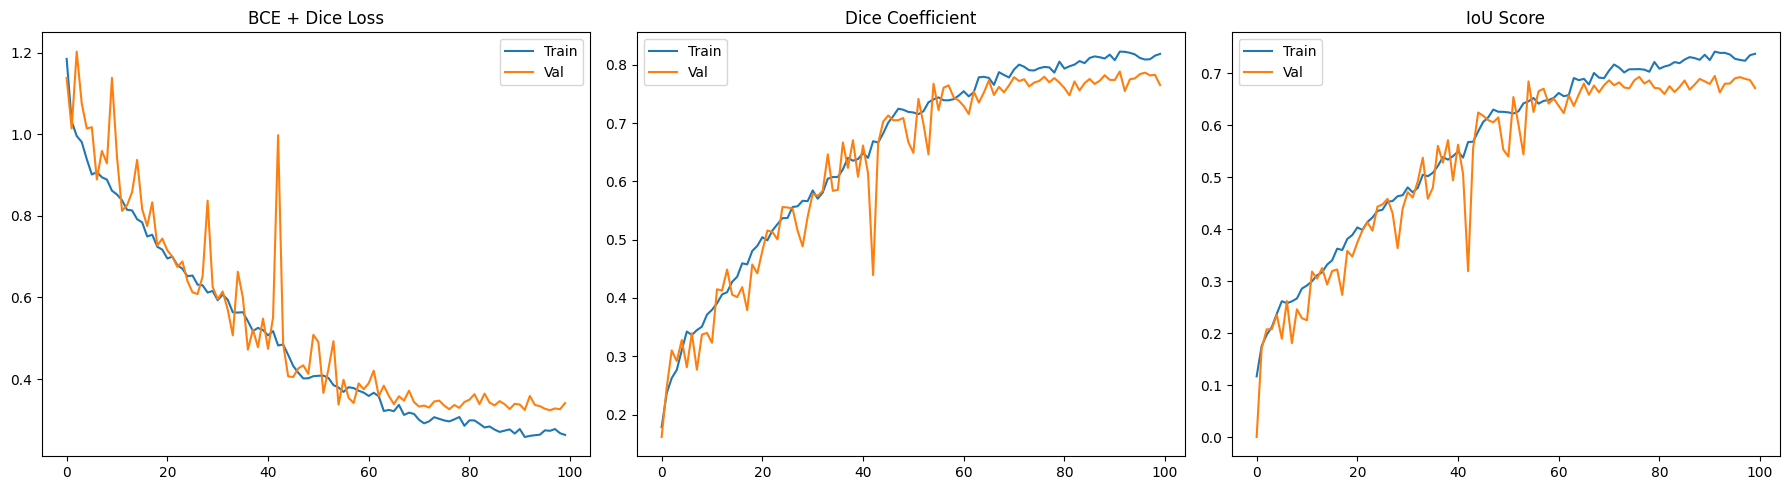

In [14]:
# ─────────────────────────────────────────────
#  MAIN RUNNER (FIXED)
# ─────────────────────────────────────────────
if __name__ == '__main__':
    # 1. Loading images from C1 to C6 folders
    images_list, masks_list = load_segmentation_paths(DATA_PATH)

    print(f"\nTotal Parsed Images: {len(images_list)} | Total Parsed Masks: {len(masks_list)}")
    if len(images_list) == 0:
        raise ValueError("No file found in the drive")

    # 2. Train and Validation fixing
    # [FIXED]: Putting images_list and masks_list
    from sklearn.model_selection import train_test_split
    train_x, val_x, train_y, val_y = train_test_split(
        images_list, masks_list, test_size=0.2, random_state=42
    )
    print(f"Train samples: {len(train_x)}  |  Val samples: {len(val_x)}")

    # 3. TF data pipeline calling
    train_ds = get_dataset(train_x, train_y, batch=BATCH_SIZE, augment_data=True)
    val_ds   = get_dataset(val_x,   val_y,   batch=BATCH_SIZE, augment_data=False)


    unet_se = build_unet_depthwise_seperable_se_lite()
    unet_se.summary()


    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    optimizer = mixed_precision.LossScaleOptimizer(optimizer)


    unet_se.compile(
        optimizer=optimizer,
        loss=bce_dice_loss,
        metrics=[dice_coef, iou_metric, 'accuracy']
    )

    os.makedirs(os.path.dirname(MODEL_SAVE), exist_ok=True)


    callbacks = [
        ModelCheckpoint(MODEL_SAVE, monitor='val_dice_coef',
                        save_best_only=True, mode='max', verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-7, verbose=1),
        EarlyStopping(monitor='val_dice_coef', patience=20,
                      restore_best_weights=True, mode='max', verbose=1),
    ]

    print("\n========== Training Started ==========")
    history = unet_se.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks
    )
    print("========== Training Complete ==========\n")


    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss Plot
    axes[0].plot(history.history['loss'],          label='Train')
    axes[0].plot(history.history['val_loss'],      label='Val')
    axes[0].set_title('BCE + Dice Loss'); axes[0].legend()


    dice_key = 'dice_coef' if 'dice_coef' in history.history else 'dice_coefficient'
    axes[1].plot(history.history[dice_key],        label='Train')
    axes[1].plot(history.history[f'val_{dice_key}'],    label='Val')
    axes[1].set_title('Dice Coefficient'); axes[1].legend()


    iou_key = 'iou_metric' if 'iou_metric' in history.history else 'mean_io_u'
    axes[2].plot(history.history[iou_key],        label='Train')
    axes[2].plot(history.history[f'val_{iou_key}'],    label='Val')
    axes[2].set_title('IoU Score'); axes[2].legend()

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()



In [15]:
#Model Summary
history_dict = history.history

# Finding the best value
best_dice = max(history_dict['dice_coef'])
best_val_dice = max(history_dict['val_dice_coef'])
best_iou = max(history_dict['iou_metric'])
best_val_iou = max(history_dict['val_iou_metric'])
min_loss = min(history_dict['loss'])
min_val_loss = min(history_dict['val_loss'])
best_acc = max(history_dict['accuracy'])
best_val_acc = max(history_dict['val_accuracy'])

print("\n" + "="*30)
print("BEST TRAINING RESULTS")
print("Pipeline Depthwise Separable 3x3, 5x5, 7x7 ---> SE Block ---> Unet")
print("="*30)
print(f"Best Training Dice:    {best_dice:.4f}")
print(f"Best Training IoU:     {best_iou:.4f}")
print(f"Best Training Acc:     {best_acc:.4f}")
print(f"Minimum Training Loss: {min_loss:.4f}")

print("\n" + "="*30)
print("   BEST VALIDATION RESULTS")
print("="*30)
print(f"Best Val Dice:         {best_val_dice:.4f}")
print(f"Best Val IoU:          {best_val_iou:.4f}")
print(f"Best Val Acc:          {best_val_acc:.4f}")
print(f"Minimum Val Loss:      {min_val_loss:.4f}")
print("="*30)


BEST TRAINING RESULTS
Pipeline Depthwise Separable 3x3, 5x5, 7x7 ---> SE Block ---> Unet
Best Training Dice:    0.8227
Best Training IoU:     0.7416
Best Training Acc:     0.9786
Minimum Training Loss: 0.2579

   BEST VALIDATION RESULTS
Best Val Dice:         0.7885
Best Val IoU:          0.6948
Best Val Acc:          0.9732
Minimum Val Loss:      0.3235


E0000 00:00:1778956020.401169    8344 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1778956022.903827    8344 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


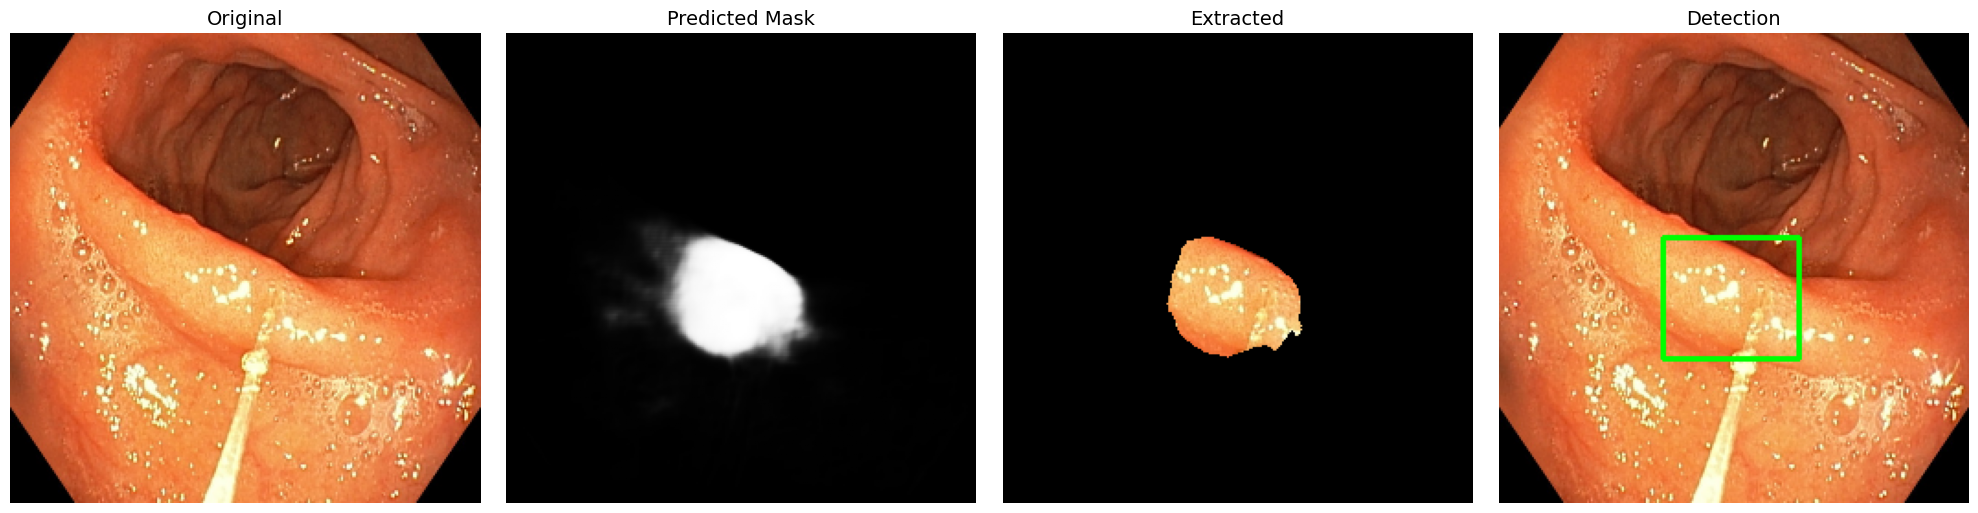

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_bounding_box(image, mask):
    # Copying image
    res_img = image.copy()
    mask_uint8 = (mask > 0.5).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        # Draw rectangle
        cv2.rectangle(res_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        # Texting on the box
        # cv2.putText(res_img, 'Polyp', (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
    return res_img

# def draw_bounding_box(image, mask):
#     res_img = image.copy()
#     mask_uint8 = (mask > 0.5).astype(np.uint8) * 255
#     contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#     pixel_to_cm_ratio = 50 
    
#     for cnt in contours:
#         area_pixel = cv2.contourArea(cnt)
#         area_cm = area_pixel / (pixel_to_cm_ratio ** 2)
#         x, y, w, h = cv2.boundingRect(cnt)
#         width_cm = w / pixel_to_cm_ratio
#         height_cm = h / pixel_to_cm_ratio
#         cv2.rectangle(res_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
#         size_text = f"{width_cm:.1f}cm x {height_cm:.1f}cm"
#         area_text = f"Area: {area_cm:.2f} cm2"
#         cv2.putText(res_img, size_text, (x, y-25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
#         cv2.putText(res_img, area_text, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
        
#     return res_img


def test_and_display(model, image_path):
    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    inp     = np.expand_dims(img_res / 255.0, axis=0).astype(np.float32)

    pred_mask = model.predict(inp, verbose=0)[0]
    

    mask_bin  = (pred_mask > 0.5).astype(np.uint8)
    mask_3d   = np.concatenate([mask_bin] * 3, axis=-1)
    extracted = (img_res * mask_3d).astype(np.uint8)


    detected_img = draw_bounding_box(img_res, pred_mask)

    titles = ['Original', 'Predicted Mask', 'Extracted', 'Detection']
    display_images = [img_res, pred_mask.squeeze(), extracted, detected_img]
    
    plt.figure(figsize=(20, 5))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        plt.imshow(display_images[i], cmap='gray' if i == 1 else None)
        plt.title(titles[i], fontsize=14)
        plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('detection_result.png', dpi=150)
    plt.show()


if images_list: 
    test_and_display(unet_se, images_list[2])

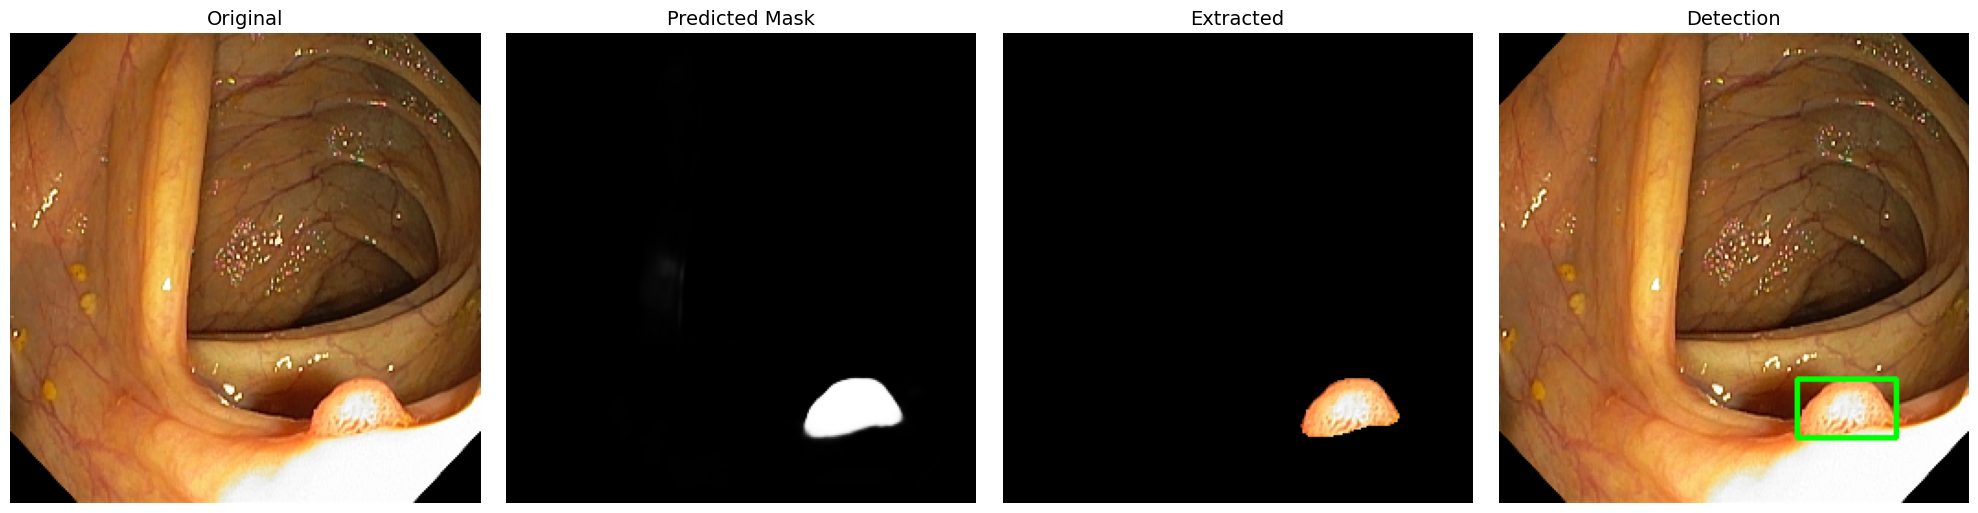

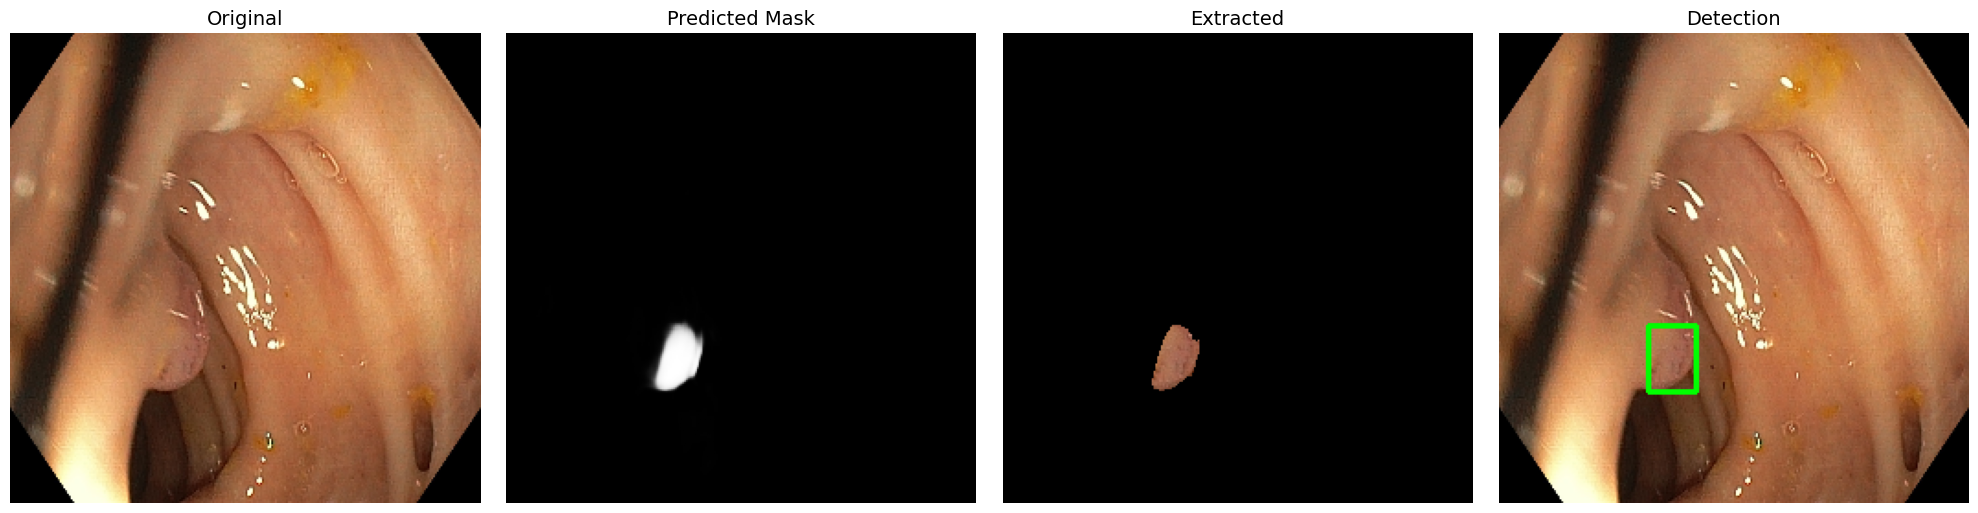

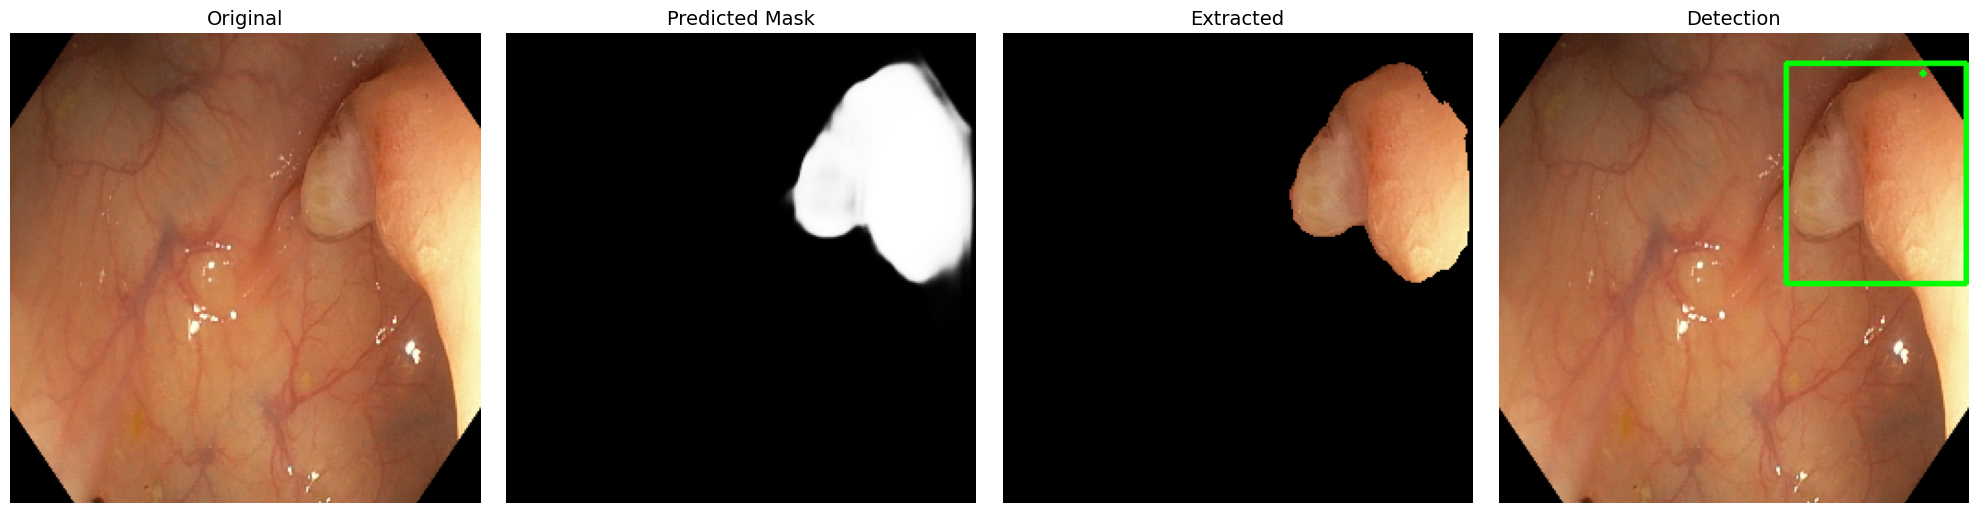

In [23]:
import random

if images_list:
    for _ in range(3):  # run 3 times
        i = random.randint(1, 25)  # random integer between 1 and 25
        test_and_display(unet_se, images_list[i])